In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Option_1_Student_Academic_Outcome.csv to Option_1_Student_Academic_Outcome.csv


In [ ]:
import pandas as pd
import io

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]), sep=';', encoding='utf-8-sig')

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(df['Target'].value_counts())
print(f"Missing: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
df.head()

Rows: 4424, Columns: 37
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Missing: 0
Duplicates: 0


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Permitted Features: 24 (Leakage removed)
Target Classes: ['Dropout' 'Graduate' 'Enrolled']


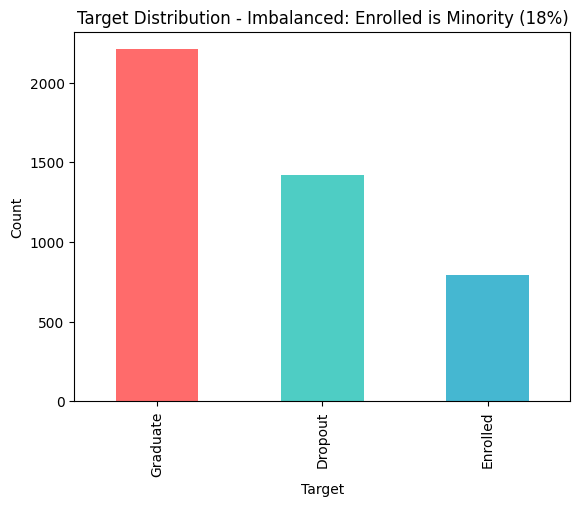

Train: (3539, 24), Test: (885, 24)

LogisticRegression_Baseline
              precision    recall  f1-score   support

     Dropout     0.6682    0.5246    0.5878       284
    Enrolled     0.2336    0.4465    0.3067       159
    Graduate     0.6927    0.5611    0.6200       442

    accuracy                         0.5288       885
   macro avg     0.5315    0.5108    0.5048       885
weighted avg     0.6024    0.5288    0.5534       885



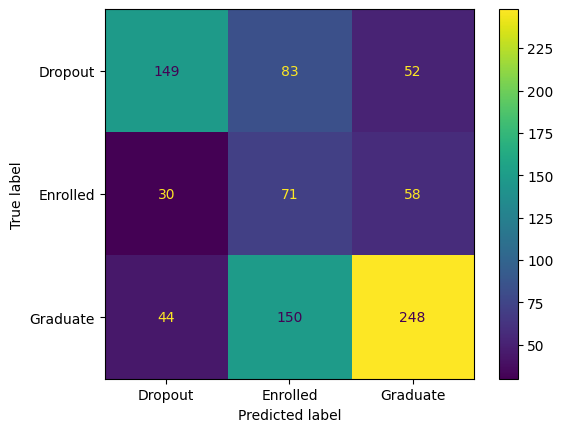

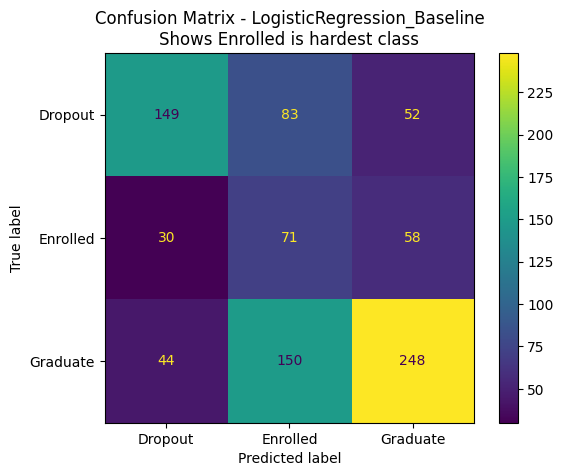


RandomForest_Final_Model
              precision    recall  f1-score   support

     Dropout     0.6320    0.5986    0.6148       284
    Enrolled     0.4107    0.1447    0.2140       159
    Graduate     0.6464    0.8190    0.7226       442

    accuracy                         0.6271       885
   macro avg     0.5630    0.5208    0.5171       885
weighted avg     0.5994    0.6271    0.5966       885



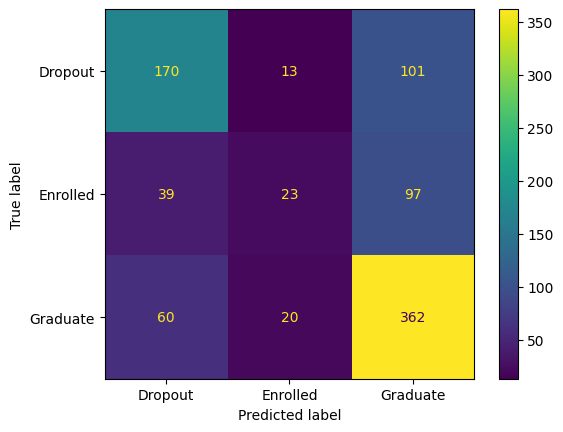

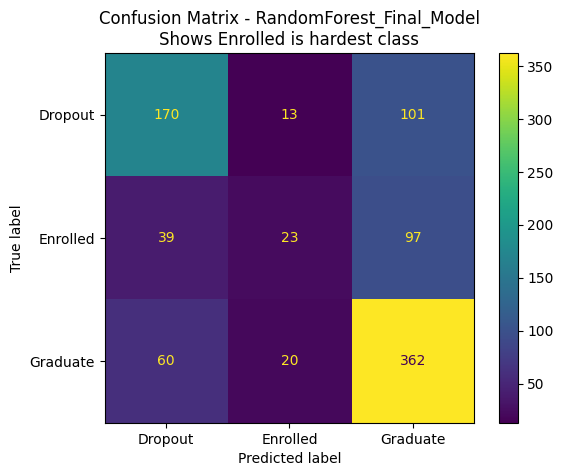


Note: Model importance does NOT prove causation, only association.


In [ ]:
# ===================================================================
# STUDENT ACADEMIC OUTCOME - LEAKAGE-SAFE MODEL EVALUATION
# Author: Sahana Gowda
# Dataset: 4424 rows, 37 cols | Target: Dropout / Enrolled / Graduate
# ===================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# -------------------------------------------------------------------
# STEP 1: IDENTIFY LEAKAGE COLUMNS
# Why remove? These 12 columns are from 1st and 2nd semester results.
# Assignment says use ONLY enrollment-time predictors.
# If we use them, model will cheat by seeing future performance.
# This is called Data Leakage.
# -------------------------------------------------------------------
LEAK_COLS = [
    "Curricular units 1st sem (credited)", "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)", "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)", "Curricular units 1st sem (without evaluations)",
    "Curricular units 2nd sem (credited)", "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)", "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)", "Curricular units 2nd sem (without evaluations)",
]

# Separate Target from Permitted Predictors (24 cols only)
X = df.drop(columns=['Target'] + LEAK_COLS)
y = df['Target']
print(f"Permitted Features: {X.shape[1]} (Leakage removed)")
print(f"Target Classes: {y.unique()}")

# -------------------------------------------------------------------
# STEP 2: EDA - TARGET DISTRIBUTION
# Shows class imbalance: Graduate 49.9% (majority), Enrolled 18% (minority)
# -------------------------------------------------------------------
df['Target'].value_counts().plot(kind='bar', color=['#FF6B6B','#4ECDC4','#45B7D1'])
plt.title('Target Distribution - Imbalanced: Enrolled is Minority (18%)')
plt.ylabel('Count')
plt.show()

# -------------------------------------------------------------------
# STEP 3: TRAIN/TEST SPLIT - LEAKAGE-SAFE
# stratify=y keeps same 49%/32%/18% ratio in train and test
# random_state=42 for reproducibility
# test_size=0.2 means final test set 885 rows remains UNSEEN during training
# -------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# -------------------------------------------------------------------
# STEP 4: PREPROCESSING WORKFLOW - FIT ONLY ON TRAIN
# SimpleImputer median + StandardScaler
# Wrapped in Pipeline so transformation is learned ONLY from X_train
# This prevents leakage from test data into training
# -------------------------------------------------------------------
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), X.columns.tolist())
])

# -------------------------------------------------------------------
# STEP 5: MODEL 1 - LOGISTIC REGRESSION (BASELINE MODEL)
# Why Baseline? Simple, fast, interpretable linear model.
# It assumes linear relationship between features and log-odds of classes.
# Good for benchmarking. Uses class_weight='balanced' to handle imbalance.
# Limitation: Cannot capture non-linear interactions (e.g., Age + Scholarship)
# -------------------------------------------------------------------
# STEP 6: MODEL 2 - RANDOM FOREST (TREE ENSEMBLE - FINAL MODEL)
# Why Tree/Ensemble? Handles encoded categorical variables naturally.
# Learns non-linear patterns: e.g., if Debtor=1 AND Tuition=0 -> High Dropout.
# 200 trees vote for final class -> more robust. Also gives feature importance.
# Uses class_weight='balanced' to give more penalty to minority class errors.
# -------------------------------------------------------------------

models = {
    "LogisticRegression_Baseline": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "RandomForest_Final_Model": RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
}

for name, model in models.items():
    # Leakage-safe pipeline: preprocessor fitted only on X_train
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    print(f"\n==============================")
    print(f"{name}")
    print(f"==============================")
    # Accuracy, Precision, Recall, F1 per-class + Macro F1
    print(classification_report(y_test, pred, digits=4))

    # Confusion Matrix - shows where model confuses Enrolled vs Dropout
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=['Dropout','Enrolled','Graduate']).plot()
    plt.title(f"Confusion Matrix - {name}\nShows Enrolled is hardest class")
    plt.show()

# -------------------------------------------------------------------
# STEP 7: FINAL MODEL JUSTIFICATION & FEATURE IMPORTANCE
# -------------------------------------------------------------------
print("\nNote: Model importance does NOT prove causation, only association.")